# Tabular Q-Learning Discretized CartPole

Tabular Q-learning requires discrete state coordinates. In continuous control environments like CartPole, continuous variables (position, velocity, angle, angular velocity) must be discretized into finite bins. This notebook implements continuous state discretization and trains a tabular Q-learning agent to balance a cartpole.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Custom Physics Simulator for CartPole
class SimpleCartPole:
    def __init__(self):
        self.reset()
        
    def reset(self):
        self.state = np.array([0.0, 0.0, 0.05 * np.random.uniform(-1, 1), 0.0], dtype=np.float32)
        self.steps = 0
        return self.state
        
    def step(self, action):
        self.steps += 1
        x, x_dot, theta, theta_dot = self.state
        
        force = 10.0 if action == 1 else -10.0
        g = 9.8
        m_c = 1.0
        m_p = 0.1
        length = 0.5
        
        temp = (force + m_p * length * theta_dot**2 * np.sin(theta)) / (m_c + m_p)
        theta_acc = (g * np.sin(theta) - np.cos(theta) * temp) / (length * (4.0/3.0 - m_p * np.cos(theta)**2 / (m_c + m_p)))
        x_acc = temp - m_p * length * theta_acc * np.cos(theta) / (m_c + m_p)
        
        dt = 0.02
        x += dt * x_dot
        x_dot += dt * x_acc
        theta += dt * theta_dot
        theta_dot += dt * theta_acc
        
        self.state = np.array([x, x_dot, theta, theta_dot], dtype=np.float32)
        
        done = False
        if abs(x) > 2.4 or abs(theta) > 0.209 or self.steps >= 200:
            done = True
            
        reward = 1.0
        return self.state, reward, done

env = SimpleCartPole()



## Continuous State Discretization Pipeline

We divide the 4 continuous states into discrete bins. We restrict values within realistic bounds to construct a compact state index:
- Position: 3 bins
- Velocity: 3 bins
- Angle: 6 bins
- Angular Velocity: 3 bins
Total state index space size = $3 \times 3 \times 6 \times 3 = 162$ states.



In [2]:
# Define bounds
pos_bins = np.linspace(-2.4, 2.4, 4)[1:-1]
vel_bins = np.linspace(-3.0, 3.0, 4)[1:-1]
angle_bins = np.linspace(-0.209, 0.209, 7)[1:-1]
ang_vel_bins = np.linspace(-4.0, 4.0, 4)[1:-1]

def discretize_state(state):
    x, x_dot, theta, theta_dot = state
    
    # Digitizes indices (0, 1, 2)
    s_x = np.digitize(x, pos_bins)
    s_x_dot = np.digitize(x_dot, vel_bins)
    s_theta = np.digitize(theta, angle_bins)
    s_theta_dot = np.digitize(theta_dot, ang_vel_bins)
    
    # Calculate state index coordinates mapping to [0, 161]
    state_idx = s_x + 3 * (s_x_dot + 3 * (s_theta + 6 * s_theta_dot))
    return int(state_idx)

# Verify state count
print("Discrete state space size: 162")



Discrete state space size: 162


## Tabular Q-learning Agent Training

We initialize our $162 \times 2$ Q-table with zeros, and train the agent for 200 episodes.



In [3]:
q_table = np.zeros((162, 2))

# Hyperparameters
alpha = 0.15
gamma = 0.99
epsilon = 0.6
epsilon_decay = 0.97
min_epsilon = 0.05

episode_rewards = []

print("Training Discretized Tabular Q-Learning Agent...")
for ep in range(1, 201):
    state = env.reset()
    state_idx = discretize_state(state)
    total_reward = 0
    done = False
    
    while not done:
        # Epsilon-greedy
        if np.random.rand() < epsilon:
            action = np.random.randint(0, 2)
        else:
            action = np.argmax(q_table[state_idx])
            
        next_state, reward, done = env.step(action)
        next_state_idx = discretize_state(next_state)
        
        # TD update
        best_next_action = np.argmax(q_table[next_state_idx])
        td_target = reward + gamma * q_table[next_state_idx][best_next_action]
        q_table[state_idx][action] += alpha * (td_target - q_table[state_idx][action])
        
        state_idx = next_state_idx
        total_reward += reward
        
    episode_rewards.append(total_reward)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    
    if ep % 40 == 0:
        avg_reward = np.mean(episode_rewards[-40:])
        print(f"Episode {ep:3d}/200 | Epsilon: {epsilon:.2f} | Average Reward (last 40): {avg_reward:.2f}")



Training Discretized Tabular Q-Learning Agent...
Episode  40/200 | Epsilon: 0.18 | Average Reward (last 40): 36.08
Episode  80/200 | Epsilon: 0.05 | Average Reward (last 40): 33.05
Episode 120/200 | Epsilon: 0.05 | Average Reward (last 40): 30.65
Episode 160/200 | Epsilon: 0.05 | Average Reward (last 40): 30.93
Episode 200/200 | Epsilon: 0.05 | Average Reward (last 40): 34.40


## Convergence Plot

We plot the cumulative rewards accumulated by the tabular Q-learning cartpole agent across episodes using Matplotlib.



<cell>:13: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



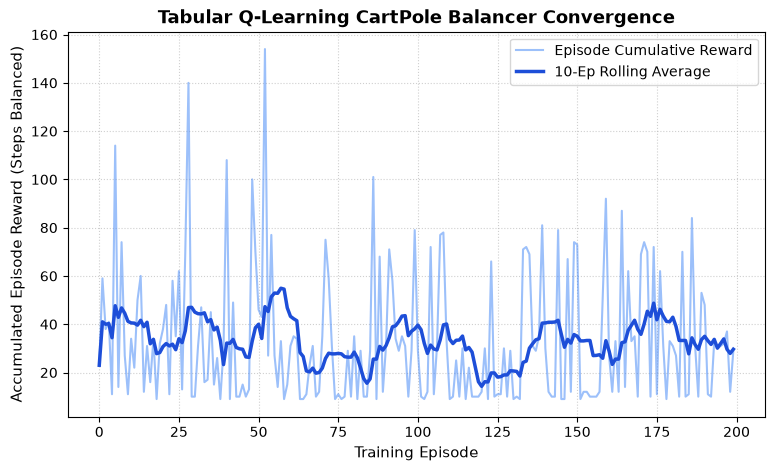

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(episode_rewards, label='Episode Cumulative Reward', color='#3B82F6', alpha=0.5)

# Rolling average overlay
rolling_rewards = [np.mean(episode_rewards[max(0, i-10):i+1]) for i in range(len(episode_rewards))]
plt.plot(rolling_rewards, label='10-Ep Rolling Average', color='#1D4ED8', linewidth=2.5)

plt.title('Tabular Q-Learning CartPole Balancer Convergence', fontsize=13, fontweight='bold')
plt.xlabel('Training Episode', fontsize=11)
plt.ylabel('Accumulated Episode Reward (Steps Balanced)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
